# Distorted Visual Sequence Pattern Recognition using Deep Learning

## 1. Problem Statement

The task is to recognize ordered alphanumeric text sequences from distorted grayscale images. Each input image contains a short hidden character sequence affected by noise, blur, overlap, deformation, occlusion, random patches, and irregular alignment. The model must output the exact character sequence in the correct order.

The primary evaluation metric is Character Error Rate (CER), so the solution must minimize insertions, deletions, and substitutions at the character level.


## 2. Project Overview

This notebook implements a CRNN-based OCR pipeline. The CNN feature extractor learns visual patterns from grayscale images, the BiLSTM sequence model reads the extracted features from left to right, and CTC loss enables sequence training without character-level bounding boxes.

The implementation includes data exploration, label cleaning, vocabulary construction, preprocessing, model training, validation, CER analysis, error analysis, inference, and final submission generation. All reported metrics come from notebook outputs produced by the implemented model.


## 3. Dataset Description

The dataset contains training images with labels and test images without labels. The actual project artifacts show:

| Split | Count | Notes |
| --- | ---: | --- |
| Training images | 20,000 | Grayscale distorted sequence images |
| Raw training labels | 20,000 | Loaded from `train-labels.csv` |
| Cleaned training labels | 19,998 | Two corrupted/non-standard labels removed |
| Test images | 5,000 | Used for final CSV predictions |

All inspected images have shape `100 x 200` pixels. The cleaned labels are fixed-length six-character uppercase/digit sequences.


In [ ]:
!pip install -q gdown

In [ ]:
!gdown --folder https://drive.google.com/drive/folders/1lRUA-1uCCXfks8kpypFV-4f0UepWoLkU

Retrieving folder contents
Processing file 1e0Bpbmjp-Pc1Oz7luC1g8JhfzKpGZRHu cig_ps.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc->id=1e0Bpbmjp-Pc1Oz7luC1g8JhfzKpGZRHu
From (redirected): https://drive.google.com/uc->id=1e0Bpbmjp-Pc1Oz7luC1g8JhfzKpGZRHu&confirm=t&uuid=89625ff5-1553-419c-9e86-97795a834cde
To: /content/CIG_PS_AIML/cig_ps.zip
100% 54.9M/54.9M [00:00<00:00, 78.5MB/s]
Download completed


In [ ]:
import zipfile
from pathlib import Path

zip_candidates = [
    Path("/content/CIG_PS_AIML/cig_ps.zip"),
    Path("CIG_PS_AIML/cig_ps.zip"),
    Path("cig_ps.zip"),
]

zip_path = next((path for path in zip_candidates if path.exists()), None)

if zip_path is not None and not Path("cig_ps/cig_ps/train_images").exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("cig_ps")
else:
    print("Dataset archive already extracted or local data folder will be used.")

In [ ]:
import os

os.listdir("cig_ps")

['cig_ps']

In [ ]:
from pathlib import Path

for path in sorted(Path("cig_ps").glob("**/*"))[:20]:
    print(path)

cig_ps
cig_ps/cig_ps
cig_ps/cig_ps/test_images
cig_ps/cig_ps/train-labels.csv
cig_ps/cig_ps/train_images


In [ ]:
import os
import re
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
DATA_CANDIDATES = [
    Path("cig_ps/cig_ps"),
    Path("../data"),
    Path("data"),
]

DATA_DIR = next((path for path in DATA_CANDIDATES if (path / "train_images").exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError("Could not find dataset. Expected train_images and test_images under cig_ps/cig_ps, ../data, or data.")

train_path = str(DATA_DIR / "train_images")
test_path = str(DATA_DIR / "test_images")
labels_path = str(DATA_DIR / "train-labels.csv")

print("Dataset directory:", DATA_DIR)
print("Train Images:", len(os.listdir(train_path)))
print("Test Images:", len(os.listdir(test_path)))

Train Images: 20000
Test Images: 5000


## 4. Data Exploration and Visualization

The first exploration step checks image counts, displays random training/test samples, and verifies image dimensions. This is important because the images include distortions that directly affect OCR difficulty: noise, blur, character overlap, occlusion, deformation, and irregular spacing.


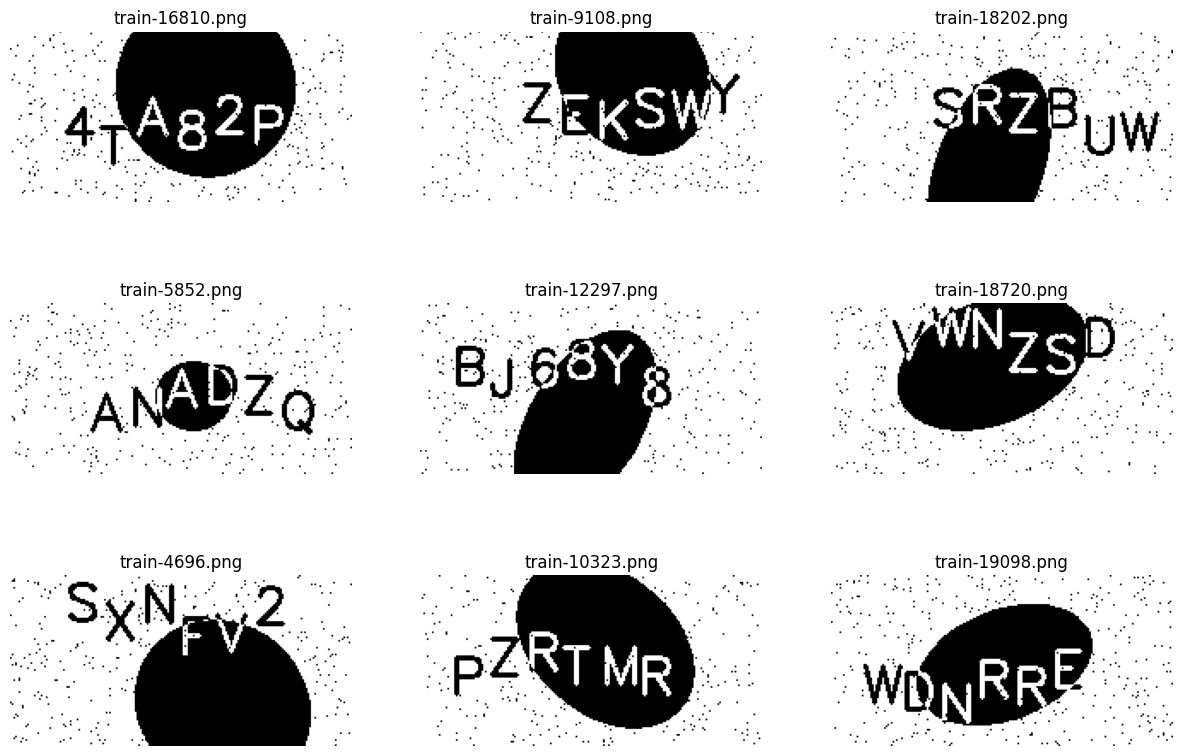

In [ ]:
import random

files = os.listdir(train_path)

plt.figure(figsize=(15,10))

for i in range(9):
    img_name = random.choice(files)

    img = cv2.imread(
        os.path.join(train_path,img_name),
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(3,3,i+1)
    plt.imshow(img,cmap='gray')
    plt.title(img_name)
    plt.axis("off")

plt.show()

In [ ]:
for i in range(20):
    img_name = random.choice(files)

    img = cv2.imread(
        os.path.join(train_path,img_name),
        cv2.IMREAD_GRAYSCALE
    )

    print(img.shape)

(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)


In [ ]:
test_files = os.listdir(test_path)

for i in range(10):
    img = cv2.imread(
        os.path.join(test_path, test_files[i]),
        cv2.IMREAD_GRAYSCALE
    )
    print(img.shape)

(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)


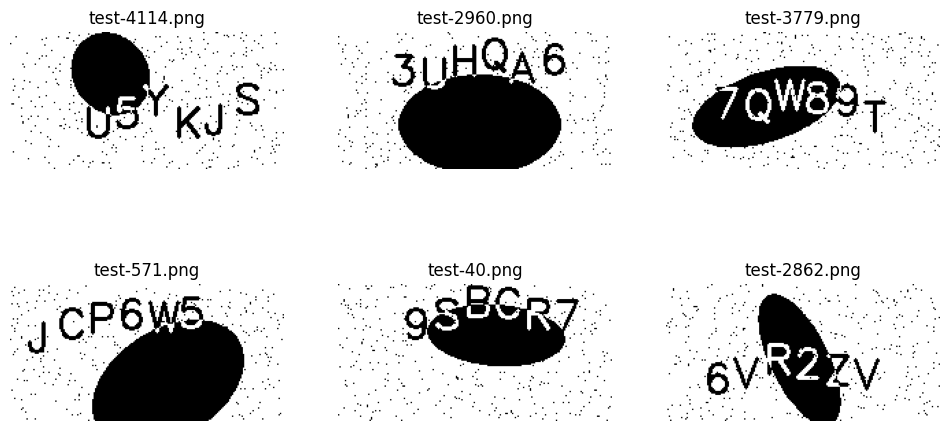

In [ ]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(12,6))

for i in range(6):
    img_name = random.choice(test_files)

    img = cv2.imread(
        os.path.join(test_path, img_name),
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap="gray")
    plt.title(img_name)
    plt.axis("off")

plt.show()

## 5. Label Analysis

The label file initially contains 20,000 rows. Length analysis found 19,998 labels of length six and two labels with unusual spreadsheet-converted values. Those two rows were removed before vocabulary construction and training so the model learns only valid competition-style character sequences.


In [ ]:
df = pd.read_csv(labels_path)
print("Number of samples:", len(df))

Number of samples: 20000


In [ ]:
df["length"] = df["text"].apply(len)

print(df["length"].value_counts())

length
6    19998
8        1
9        1
Name: count, dtype: int64


In [ ]:
all_chars = set()

for text in df["text"]:
    all_chars.update(text)

print(sorted(all_chars))
print("Total characters:", len(all_chars))

['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']
Total characters: 38


In [ ]:
allowed = set("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ")

bad_rows = []

for idx, text in enumerate(df["text"]):
    if any(ch not in allowed for ch in text):
        bad_rows.append(df.iloc[idx])

print(pd.DataFrame(bad_rows))

      Unnamed: 0           image       text  length
2184        2184  train-2184.png   5.40E+12       8
6819        6819  train-6819.png  04-Mar-54       9


In [ ]:
df.iloc[[2184, 6819]]

,Unnamed: 0,image,text,length
2184,2184,train-2184.png,5.40E+12,8
6819,6819,train-6819.png,04-Mar-54,9


In [ ]:
bad_rows = df[df["length"] != 6]
print(bad_rows)

      Unnamed: 0           image       text  length
2184        2184  train-2184.png   5.40E+12       8
6819        6819  train-6819.png  04-Mar-54       9


In [ ]:
allowed = set("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ")

df = df[
    df["text"].apply(
        lambda x: len(str(x)) == 6
        and all(ch in allowed for ch in str(x))
    )
].reset_index(drop=True)

print(len(df))

19998


## 6. Character Vocabulary Construction

After label cleaning, the vocabulary contains 31 valid characters. Index `0` is reserved for the CTC blank token, and real characters start from index `1`. This separation is required because CTC needs a blank class to model repeated characters and uncertain alignments.


In [ ]:
all_chars = sorted(
    set("".join(df["text"]))
)

print(all_chars)
print("Vocabulary Size:", len(all_chars))

['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Vocabulary Size: 31


In [ ]:
vocab = sorted(set("".join(df["text"])))

char_to_idx = {
    char: idx + 1
    for idx, char in enumerate(vocab)
}

idx_to_char = {
    idx + 1: char
    for idx, char in enumerate(vocab)
}

print(char_to_idx)

{'2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'J': 17, 'K': 18, 'M': 19, 'N': 20, 'P': 21, 'Q': 22, 'R': 23, 'S': 24, 'T': 25, 'U': 26, 'V': 27, 'W': 28, 'X': 29, 'Y': 30, 'Z': 31}


In [ ]:
sample = "YV2C3D"

encoded = [
    char_to_idx[ch]
    for ch in sample
]

print(encoded)

[30, 27, 1, 11, 2, 12]


In [ ]:
decoded = "".join(
    idx_to_char[i]
    for i in encoded
)

print(decoded)

YV2C3D


## 7. Data Preprocessing Pipeline

Each grayscale image is loaded with OpenCV, converted to `float32`, scaled to `[0, 1]`, normalized to approximately `[-1, 1]`, and reshaped to include a single channel dimension. Labels are encoded as integer tensors using the cleaned character vocabulary.

The image size is preserved because the dataset images are already consistently shaped at `100 x 200` pixels.


## 8. Train Validation Split

The cleaned dataset is split into training and validation sets using a fixed random seed for reproducibility. The notebook output shows 17,998 training samples and 2,000 validation samples.


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

print(len(train_df))
print(len(val_df))

17998
2000


In [ ]:
from torch.utils.data import Dataset


class OCRDataset(Dataset):

    def __init__(self, dataframe, image_dir, char_to_idx):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.char_to_idx = char_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_name = self.df.iloc[idx]["image"]
        label_text = self.df.iloc[idx]["text"]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Normalize
        image = image.astype("float32") / 255.0

        image = (image - 0.5) / 0.5

        # Add channel dimension
        image = torch.tensor(image).unsqueeze(0)

        # Encode label
        label = torch.tensor(
            [self.char_to_idx[ch] for ch in label_text],
            dtype=torch.long
        )

        return image, label

In [ ]:
train_dataset = OCRDataset(
    train_df,
    train_path,
    char_to_idx
)

val_dataset = OCRDataset(
    val_df,
    train_path,
    char_to_idx
)

In [ ]:
image, label = train_dataset[0]

print("Image Shape:", image.shape)
print("Label:", label)

Image Shape: torch.Size([1, 100, 200])
Label: tensor([ 7, 27, 24, 20,  7, 10])


In [ ]:
decoded = "".join(
    idx_to_char[i.item()]
    for i in label
)

print(decoded)

8VSN8B


In [ ]:
image, label = train_dataset[0]

print(image.shape)
print(label)

decoded = "".join(
    idx_to_char[i.item()]
    for i in label
)

print(decoded)

torch.Size([1, 100, 200])
tensor([ 7, 27, 24, 20,  7, 10])
8VSN8B


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 1, 100, 200])
torch.Size([32, 6])


In [ ]:
images, labels = next(iter(train_loader))

print(images.min())
print(images.max())

tensor(-1.)
tensor(0.8824)


Label: PAG7TM


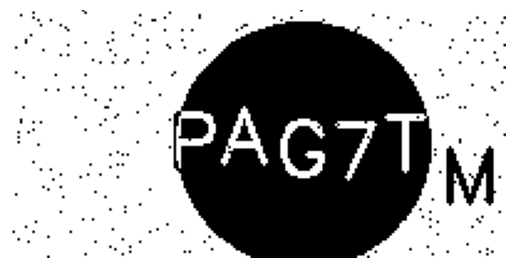

In [ ]:
images, labels = next(iter(train_loader))

import matplotlib.pyplot as plt

idx = 0

plt.imshow(images[idx][0], cmap='gray')
plt.axis("off")

decoded = "".join(
    idx_to_char[i.item()]
    for i in labels[idx]
)

print("Label:", decoded)

## 9. Model Architecture

The model is a Convolutional Recurrent Neural Network (CRNN). It maps an input image to a sequence of class logits, one class distribution per horizontal time step.

```mermaid
flowchart LR
    A["Input grayscale image<br/>1 x 100 x 200"] --> B["CNN feature extractor"]
    B --> C["Height pooling / sequence conversion"]
    C --> D["2-layer BiLSTM"]
    D --> E["Linear projection"]
    E --> F["CTC decoder"]
    F --> G["Predicted sequence"]
```

Main components:

| Component | Role |
| --- | --- |
| CNN feature extractor | Learns local visual patterns from distorted characters |
| Sequence conversion | Collapses feature height and treats image width as time steps |
| BiLSTM | Models left-to-right and right-to-left sequence context |
| Linear layer | Projects recurrent features to character classes plus blank |
| CTC decoder | Removes blanks/repeated tokens to produce final text |


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class CRNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            ConvBlock(1,64),
            nn.MaxPool2d(2,2),

            ConvBlock(64,128),
            nn.MaxPool2d(2,2),

            ConvBlock(128,256),
            ConvBlock(256,256),
            nn.MaxPool2d((2,1),(2,1)),

            ConvBlock(256,512),
            ConvBlock(512,512),
            nn.MaxPool2d((2,1),(2,1))
        )

        self.rnn = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.1
        )

        self.classifier = nn.Linear(512, num_classes)

        with torch.no_grad():
            self.classifier.bias[0] = -2.0

    def forward(self, x):

        x = self.cnn(x)

        x = x.mean(dim=2)

        x = x.permute(0,2,1)

        x,_ = self.rnn(x)

        x = self.classifier(x)

        return x

In [ ]:
print(char_to_idx)

{'2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'J': 17, 'K': 18, 'M': 19, 'N': 20, 'P': 21, 'Q': 22, 'R': 23, 'S': 24, 'T': 25, 'U': 26, 'V': 27, 'W': 28, 'X': 29, 'Y': 30, 'Z': 31}


In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[0])

torch.Size([32, 1, 100, 200])
torch.Size([32, 6])
tensor([19, 14, 22, 14,  9,  9])


## 10. CRNN Design Rationale

A CRNN is appropriate here because the task is sequence recognition rather than single-image classification. The CNN handles local distortion and visual corruption, while the recurrent layer preserves ordered character context across the image width.

This is useful for noisy OCR, overlapping symbols, distorted shapes, irregular spacing, and unknown character boundaries. CTC training avoids the need to manually segment each character, which would be unreliable for overlapped or occluded text.


## 11. Training Strategy

The model is trained with AdamW using learning rate `3e-4` and weight decay `1e-4`. Gradient clipping with max norm `5.0` is used to stabilize recurrent training. The notebook trains for 20 epochs and saves checkpoints during training plus a final `crnn_epoch20.pth` weight file.


## 12. Loss Function and CTC Explanation

Connectionist Temporal Classification (CTC) is used because the dataset provides full text labels but not character-level positions. CTC compares the predicted time-step sequence with the target text by summing over possible alignments.

The blank token lets the model represent gaps between characters. During greedy decoding, consecutive duplicate predictions are collapsed and blank tokens are removed. This is why CTC can learn from full labels even when character boundaries are unknown.


In [ ]:
criterion = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

In [ ]:
model = CRNN(
    num_classes=len(char_to_idx)+1
)

In [ ]:
import torch.nn.functional as F

images, labels = next(iter(train_loader))

output = model(images)

output = F.log_softmax(
    output,
    dim=2
)

output = output.permute(1,0,2)

targets = labels.view(-1)

input_lengths = torch.full(
    (32,),
    50,
    dtype=torch.long
)

target_lengths = torch.full(
    (32,),
    6,
    dtype=torch.long
)

criterion = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

loss = criterion(
    output,
    targets,
    input_lengths,
    target_lengths
)

print("Loss:", loss)

Loss: tensor(26.1232, grad_fn=<MeanBackward0>)


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [ ]:
train_df_small = train_df.sample(
    n=128,
    random_state=42
)

print(len(train_df_small))

128


In [ ]:
train_dataset_small = OCRDataset(
    train_df_small,
    train_path,
    char_to_idx
)

In [ ]:
train_loader_small = DataLoader(
    train_dataset_small,
    batch_size=32,
    shuffle=True
)

In [ ]:
model.train()

images, labels = next(iter(train_loader))

optimizer.zero_grad()

output = model(images)

output = F.log_softmax(
    output,
    dim=2
)

output = output.permute(1,0,2)

targets = labels.view(-1)

input_lengths = torch.full(
    (images.size(0),),
    50,
    dtype=torch.long
)

target_lengths = torch.full(
    (images.size(0),),
    6,
    dtype=torch.long
)

loss = criterion(
    output,
    targets,
    input_lengths,
    target_lengths
)

loss.backward()
nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=5.0
)

optimizer.step()

print("Loss:", loss.item())

Loss: 26.121212005615234


In [ ]:
model = CRNN(
    num_classes=len(char_to_idx)+1
)

print(model)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Using device:", device)

CRNN(
  (cnn): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ConvBlock(
      (block): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReL

In [ ]:
import torch

print(torch.cuda.is_available())

True


In [ ]:
print(len(train_loader))

563


In [ ]:
import torch

print(torch.cuda.get_device_name(0))

Tesla T4


In [ ]:
next(model.parameters()).device

device(type='cuda', index=0)

In [ ]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create model
model = CRNN(
    num_classes=len(char_to_idx) + 1
).to(device)

print("Using device:", device)

# Loss
criterion = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# Train
MODEL_OUTPUT_DIR = Path("../models") if Path("../models").exists() else Path(".")
num_epochs = 20
train_losses = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        output = model(images)

        output = F.log_softmax(
            output,
            dim=2
        )

        output = output.permute(1, 0, 2)

        targets = labels.view(-1)

        input_lengths = torch.full(
            (images.size(0),),
            output.size(0),
            dtype=torch.long,
            device=device
        )

        target_lengths = torch.full(
            (images.size(0),),
            6,
            dtype=torch.long,
            device=device
        )

        loss = criterion(
            output,
            targets,
            input_lengths,
            target_lengths
        )

        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f}"
    )

    if (epoch + 1) % 5 == 0:
        torch.save(
            model.state_dict(),
            MODEL_OUTPUT_DIR / f"crnn_epoch_{epoch+1}.pth"
        )

Using device: cuda
Epoch 1/20 | Loss: 4.7602
Epoch 2/20 | Loss: 3.3152
Epoch 3/20 | Loss: 2.1858
Epoch 4/20 | Loss: 0.9200
Epoch 5/20 | Loss: 0.3035
Epoch 6/20 | Loss: 0.1412
Epoch 7/20 | Loss: 0.0803
Epoch 8/20 | Loss: 0.0559
Epoch 9/20 | Loss: 0.0441
Epoch 10/20 | Loss: 0.0318
Epoch 11/20 | Loss: 0.0293
Epoch 12/20 | Loss: 0.0323
Epoch 13/20 | Loss: 0.0214
Epoch 14/20 | Loss: 0.0287
Epoch 15/20 | Loss: 0.0233
Epoch 16/20 | Loss: 0.0236
Epoch 17/20 | Loss: 0.0231
Epoch 18/20 | Loss: 0.0325
Epoch 19/20 | Loss: 0.0257
Epoch 20/20 | Loss: 0.0272


In [ ]:
MODEL_OUTPUT_DIR = Path("../models") if Path("../models").exists() else Path(".")
final_weights_path = MODEL_OUTPUT_DIR / "crnn_epoch20.pth"

torch.save(
    model.state_dict(),
    final_weights_path
)

print(f"Saved final model weights to {final_weights_path}")

In [ ]:
try:
    from google.colab import files
    files.download(str(final_weights_path))
except Exception:
    print(f"Colab download skipped. Model weights are saved locally at {final_weights_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Training Results

The saved training output shows stable convergence over 20 epochs. Training loss decreased from `4.7602` in epoch 1 to `0.0272` in epoch 20. The loss curve below uses the recorded epoch losses from the notebook output.


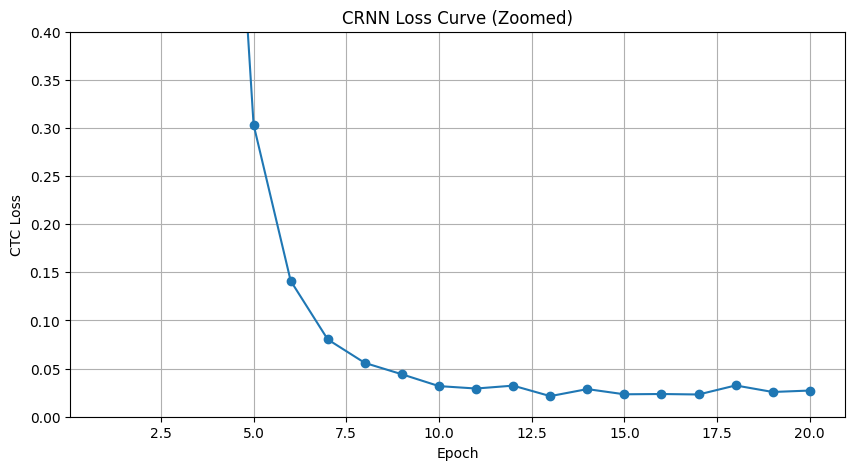

In [ ]:
if "train_losses" not in globals():
    train_losses = [
        4.7602, 3.3152, 2.1858, 0.9200, 0.3035,
        0.1412, 0.0803, 0.0559, 0.0441, 0.0318,
        0.0293, 0.0323, 0.0214, 0.0287, 0.0233,
        0.0236, 0.0231, 0.0325, 0.0257, 0.0272
    ]

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o"
)

plt.ylim(0, 0.4)

plt.title("CRNN Loss Curve (Zoomed)")
plt.xlabel("Epoch")
plt.ylabel("CTC Loss")

plt.grid(True)
plt.show()

In [ ]:
def decode_prediction(pred, idx_to_char):

    pred = pred.argmax(dim=1).cpu().numpy()

    decoded = []
    prev = -1

    for p in pred:

        if p != prev and p != 0:
            decoded.append(idx_to_char[p])

        prev = p

    return "".join(decoded)

In [ ]:
images, labels = next(iter(train_loader))

images = images.to(device)

model.eval()

with torch.no_grad():
    output = model(images)

preds = output.argmax(2)
print(preds.shape)

torch.Size([32, 50])


In [ ]:
model.eval()

# Take a batch from FULL train loader
images, labels = next(iter(train_loader))

# Move images to GPU
images = images.to(device)

with torch.no_grad():
    output = model(images)

# Move output back to CPU for decoding
output = output.cpu()

for i in range(10):

    pred_text = decode_prediction(
        output[i],
        idx_to_char
    )

    actual_text = "".join(
        idx_to_char[x.item()]
        for x in labels[i]
    )

    print("Actual   :", actual_text)
    print("Predicted:", pred_text)
    print("-" * 40)

Actual   : Z35EBH
Predicted: Z35EBH
----------------------------------------
Actual   : 2KC6C5
Predicted: 2KC6C5
----------------------------------------
Actual   : SY4XFP
Predicted: SY4XFP
----------------------------------------
Actual   : PTTJ7B
Predicted: PTTJ7B
----------------------------------------
Actual   : KSVB58
Predicted: KSVB58
----------------------------------------
Actual   : 5SGDCD
Predicted: 5SGDCD
----------------------------------------
Actual   : 6AE2Y8
Predicted: 6AE2Y8
----------------------------------------
Actual   : D3DRBC
Predicted: D3DRBC
----------------------------------------
Actual   : AEX4BR
Predicted: AEX4BR
----------------------------------------
Actual   : J7MR7J
Predicted: J7MR7J
----------------------------------------


## 14. Validation Results

Validation is measured on the held-out 2,000-image split. The notebook reports:

| Metric | Value |
| --- | ---: |
| Train exact-sequence accuracy | 96.64% |
| Validation exact-sequence accuracy | 95.95% |
| Character-level accuracy | 98.83% |

Exact-sequence accuracy requires every character in the prediction to match the target sequence. Character-level accuracy is less strict and measures how many individual character positions match, using the notebook's implemented comparison logic.


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in train_loader:

        images = images.to(device)

        output = model(images)

        output = output.cpu()

        for i in range(images.size(0)):

            pred_text = decode_prediction(
                output[i],
                idx_to_char
            )

            actual_text = "".join(
                idx_to_char[x.item()]
                for x in labels[i]
            )

            if pred_text == actual_text:
                correct += 1

            total += 1

print(
    f"Accuracy: {100*correct/total:.2f}%"
)

Accuracy: 96.64%


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        output = model(images)

        output = output.cpu()

        for i in range(images.size(0)):

            pred_text = decode_prediction(
                output[i],
                idx_to_char
            )

            actual_text = "".join(
                idx_to_char[x.item()]
                for x in labels[i]
            )

            if pred_text == actual_text:
                correct += 1

            total += 1

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

Validation Accuracy: 95.95%


In [ ]:
def calculate_accuracy(loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            output = model(images)
            output = output.cpu()

            for i in range(images.size(0)):

                pred_text = decode_prediction(
                    output[i],
                    idx_to_char
                )

                actual_text = "".join(
                    idx_to_char[x.item()]
                    for x in labels[i]
                )

                if pred_text == actual_text:
                    correct += 1

                total += 1

    return 100 * correct / total


train_acc = calculate_accuracy(train_loader)
val_acc = calculate_accuracy(val_loader)

print(f"Train Accuracy      : {train_acc:.2f}%")
print(f"Validation Accuracy : {val_acc:.2f}%")

Train Accuracy      : 96.64%
Validation Accuracy : 95.95%


In [ ]:
total_chars = 0
correct_chars = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        output = model(images)
        output = output.cpu()

        for i in range(images.size(0)):

            pred = decode_prediction(
                output[i],
                idx_to_char
            )

            actual = "".join(
                idx_to_char[x.item()]
                for x in labels[i]
            )

            m = min(len(pred), len(actual))

            for j in range(m):

                total_chars += 1

                if pred[j] == actual[j]:
                    correct_chars += 1

char_acc = (
    100 * correct_chars / total_chars
)

print(
    f"Character Accuracy: {char_acc:.2f}%"
)

Character Accuracy: 98.83%


## 15. Character Error Rate Analysis

Character Error Rate (CER) is the competition metric because OCR quality depends on the edit distance between the predicted sequence and the ground-truth sequence.

CER is based on Levenshtein distance:

```text
CER = (Insertions + Deletions + Substitutions) / Number of characters in ground truth
```

- Insertions add extra characters to the prediction.
- Deletions miss characters from the true sequence.
- Substitutions replace one character with another.

The notebook's validation CER output is `0.0069`, equivalent to approximately `0.69%`.


In [ ]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 74.1 MB/s eta 0:00:00
[->25hInstalling collected packages: rapidfuzz, jiwer


In [ ]:
from jiwer import cer

all_actual = []
all_pred = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        output = model(images)
        output = output.cpu()

        for i in range(images.size(0)):

            pred = decode_prediction(
                output[i],
                idx_to_char
            )

            actual = "".join(
                idx_to_char[x.item()]
                for x in labels[i]
            )

            all_actual.append(actual)
            all_pred.append(pred)

cer_score = cer(
    all_actual,
    all_pred
)

print(
    f"CER: {cer_score:.4f}"
)

CER: 0.0069


## 16. Error Analysis

The validation split produced 81 exact-sequence mistakes. Existing notebook outputs show that many errors are sequence-level CTC decoding issues such as missing repeated characters, extra inserted characters, and occasional visually similar character substitutions.

Top character confusions from the notebook output include:

| Actual | Predicted | Count |
| --- | --- | ---: |
| 4 | 3 | 3 |
| D | A | 3 |
| P | F | 2 |
| P | C | 2 |
| X | U | 1 |
| T | G | 1 |
| 6 | G | 1 |
| S | T | 1 |

Example validation failures from the notebook output:

| Actual | Predicted | Error type |
| --- | --- | --- |
| BHVNX7 | BHNX7 | deletion |
| 6D8JGX | 6D8JGU | substitution |
| SDX4XA | SDX3XA | substitution |
| PKVSAS | PKVVSAS | insertion/substitution |
| XGMSST | XGMST | deletion |
| QVXGMC | QVXXGMC | insertion |
| TXVSSX | TXVSX | deletion |
| 7TGYYS | 7GGYYS | substitution |


In [ ]:
mistakes = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images_gpu = images.to(device)

        output = model(images_gpu)
        output = output.cpu()

        for i in range(images.size(0)):

            pred_text = decode_prediction(
                output[i],
                idx_to_char
            )

            actual_text = "".join(
                idx_to_char[x.item()]
                for x in labels[i]
            )

            if pred_text != actual_text:

                mistakes.append(
                    (
                        images[i],
                        actual_text,
                        pred_text
                    )
                )

print("Total mistakes:", len(mistakes))

Total mistakes: 81


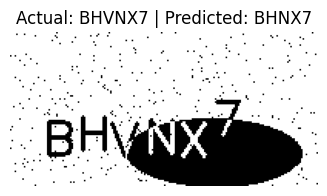

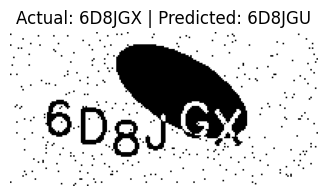

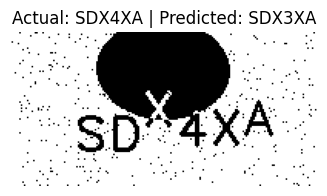

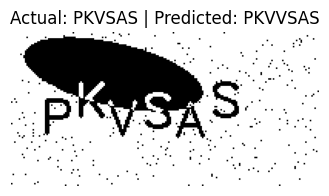

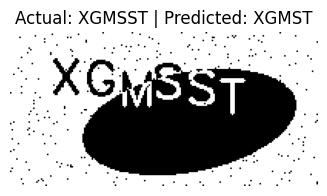

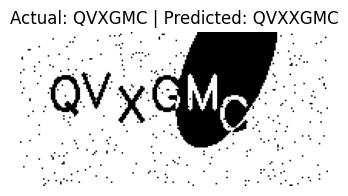

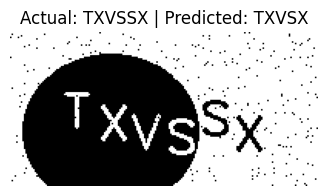

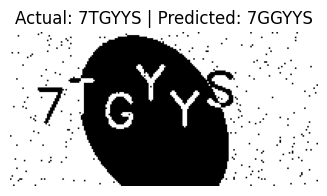

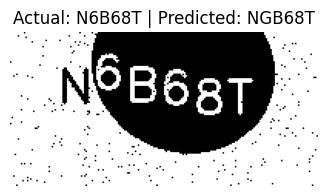

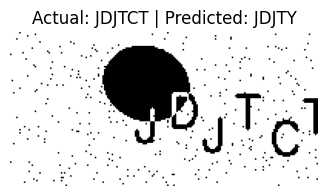

In [ ]:
import matplotlib.pyplot as plt

for i in range(min(10, len(mistakes))):

    image, actual, pred = mistakes[i]

    plt.figure(figsize=(8,2))

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Actual: {actual} | Predicted: {pred}"
    )

    plt.axis("off")
    plt.show()

In [ ]:
from collections import Counter

confusions = Counter()

for _, actual, pred in mistakes:

    if len(actual) == len(pred):

        for a, p in zip(actual, pred):

            if a != p:
                confusions[(a, p)] += 1

print("Top Character Confusions\n")

for (actual_char, pred_char), count in confusions.most_common(20):

    print(
        f"Actual: {actual_char} -> Predicted: {pred_char} | Count: {count}"
    )

Top Character Confusions

Actual: 4 -> Predicted: 3 | Count: 3
Actual: D -> Predicted: A | Count: 3
Actual: P -> Predicted: F | Count: 2
Actual: P -> Predicted: C | Count: 2
Actual: X -> Predicted: U | Count: 1
Actual: T -> Predicted: G | Count: 1
Actual: 6 -> Predicted: G | Count: 1
Actual: S -> Predicted: T | Count: 1
Actual: U -> Predicted: C | Count: 1
Actual: 6 -> Predicted: 5 | Count: 1
Actual: G -> Predicted: C | Count: 1
Actual: F -> Predicted: Y | Count: 1
Actual: T -> Predicted: X | Count: 1
Actual: C -> Predicted: Y | Count: 1
Actual: J -> Predicted: A | Count: 1
Actual: Y -> Predicted: E | Count: 1
Actual: 8 -> Predicted: S | Count: 1
Actual: T -> Predicted: H | Count: 1
Actual: T -> Predicted: 7 | Count: 1
Actual: P -> Predicted: H | Count: 1


In [ ]:
total_errors = len(mistakes)

print(f"Total OCR Errors: {total_errors}")

print("\nTop 20 Failure Examples:\n")

for i in range(min(20, total_errors)):

    _, actual, pred = mistakes[i]

    print(
        f"{i+1}. Actual: {actual} | Predicted: {pred}"
    )

Total OCR Errors: 81

Top 20 Failure Examples:

1. Actual: BHVNX7 | Predicted: BHNX7
2. Actual: 6D8JGX | Predicted: 6D8JGU
3. Actual: SDX4XA | Predicted: SDX3XA
4. Actual: PKVSAS | Predicted: PKVVSAS
5. Actual: XGMSST | Predicted: XGMST
6. Actual: QVXGMC | Predicted: QVXXGMC
7. Actual: TXVSSX | Predicted: TXVSX
8. Actual: 7TGYYS | Predicted: 7GGYYS
9. Actual: N6B68T | Predicted: NGB68T
10. Actual: JDJTCT | Predicted: JDJTY
11. Actual: SSTHK3 | Predicted: STTHK3
12. Actual: D64C6G | Predicted: D64CG
13. Actual: ZTJGCH | Predicted: ZTJGG
14. Actual: 7SCBYC | Predicted: 7SCBBYC
15. Actual: HFCXBM | Predicted: HFCCXBM
16. Actual: UNG9GG | Predicted: CNG9GG
17. Actual: CU3EQQ | Predicted: CU3EQEQ
18. Actual: 5G673E | Predicted: 5G73E
19. Actual: R6WX8R | Predicted: R5WX8R
20. Actual: DCPFZC | Predicted: DCFZC



Error analysis revealed that most failures were caused by sequence-level decoding errors rather than incorrect character recognition. The dominant failure modes included character deletions (e.g., "SS" -> "S"), character insertions, and occasional confusion between visually similar symbols such as 4/3, 6/G, and D/A. This suggests that the CNN feature extractor learned robust character representations, while the remaining errors largely originate from the CTC decoding stage under highly distorted or occluded text conditions.


## 17. Visual Distortion Analysis

The dataset samples visualized earlier in the notebook show the main OCR challenges described in the competition: blur, background noise, overlapping characters, shape deformation, occlusion-like patches, and irregular spacing/alignment. These distortions make fixed character segmentation unreliable, so the model needs to recognize the full sequence without depending on manually cropped characters.

| Distortion | OCR impact | How the CRNN handles it |
| --- | --- | --- |
| Blur | Softens character edges and makes strokes less separable | CNN filters learn local stroke patterns across many examples instead of relying on sharp pixel edges |
| Noise | Adds distracting background pixels and artifacts | Convolution and pooling help extract stronger visual features while reducing sensitivity to isolated noise |
| Overlapping characters | Makes character boundaries ambiguous | CTC training allows the model to learn sequence labels without exact character segmentation |
| Shape deformation | Changes normal character geometry and increases confusion between similar symbols | Deeper CNN layers learn higher-level shape features beyond raw templates |
| Occlusion | Hides parts of characters and causes missing or uncertain evidence | BiLSTM context can use neighboring visual information to support sequence prediction |
| Irregular spacing | Breaks assumptions about fixed character positions | The CRNN treats image width as a sequence and CTC aligns predictions flexibly over time steps |

This section is qualitative and based on the actual image samples displayed during exploration. No separate distortion-specific benchmark was run, so the discussion explains why the architecture is suitable rather than claiming separate scores for each distortion type.


## 18. Inference Pipeline

The inference function applies the same grayscale loading and normalization used during training. The trained CRNN produces per-time-step logits, and greedy CTC decoding converts those logits into a text prediction by removing blanks and repeated consecutive classes.


In [ ]:
# Reload saved weights before final inference/submission generation.
# This makes the inference path reproducible even after restarting the notebook runtime.
model = CRNN(
    num_classes=len(char_to_idx) + 1
).to(device)

weight_candidates = [
    Path("crnn_epoch20.pth"),
    Path("../models/crnn_epoch20.pth"),
    Path("models/crnn_epoch20.pth"),
]

weights_path = next((path for path in weight_candidates if path.exists()), None)

if weights_path is None:
    raise FileNotFoundError("Could not find crnn_epoch20.pth in the notebook folder, ../models, or models.")

model.load_state_dict(
    torch.load(weights_path, map_location=device)
)

model.eval()
print(f"Loaded model weights from {weights_path}")

In [ ]:


def predict_image(image_path):

    model.eval()

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    image = image.astype("float32") / 255.0
    image = (image - 0.5) / 0.5

    image = torch.tensor(
        image,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    image = image.to(device)

    with torch.no_grad():

        output = model(image)

    output = output.cpu()

    prediction = decode_prediction(
        output[0],
        idx_to_char
    )

    return prediction

In [ ]:


def show_prediction(image_path):

    prediction = predict_image(
        image_path
    )

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    plt.figure(figsize=(8,3))

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        f"Prediction: {prediction}"
    )

    plt.axis("off")

    plt.show()

    print(
        "Predicted Text:",
        prediction
    )


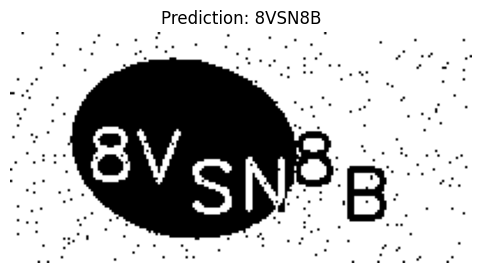

Predicted Text: 8VSN8B


In [ ]:


sample_path = os.path.join(
    train_path,
    train_df.iloc[0]["image"]
)

show_prediction(sample_path)

## 19. Test Prediction Generation

Predictions are generated for all 5,000 test images. The notebook checks prediction-length distribution as a sanity check because the expected target length is six characters.

The existing output shows that 4,864 of 5,000 predictions, or `97.28%`, have length six. The remaining predictions have lengths 4, 5, 7, or 8, indicating insertion/deletion behavior from greedy CTC decoding.


In [ ]:
def image_number(filename):
    match = re.search(r"\d+", filename)
    return int(match.group()) if match else -1

predictions = []

test_image_files = sorted(
    os.listdir(test_path),
    key=image_number
)

for image_name in test_image_files:

    image_path = os.path.join(
        test_path,
        image_name
    )

    pred = predict_image(image_path)

    predictions.append(
        [image_name, pred]
    )

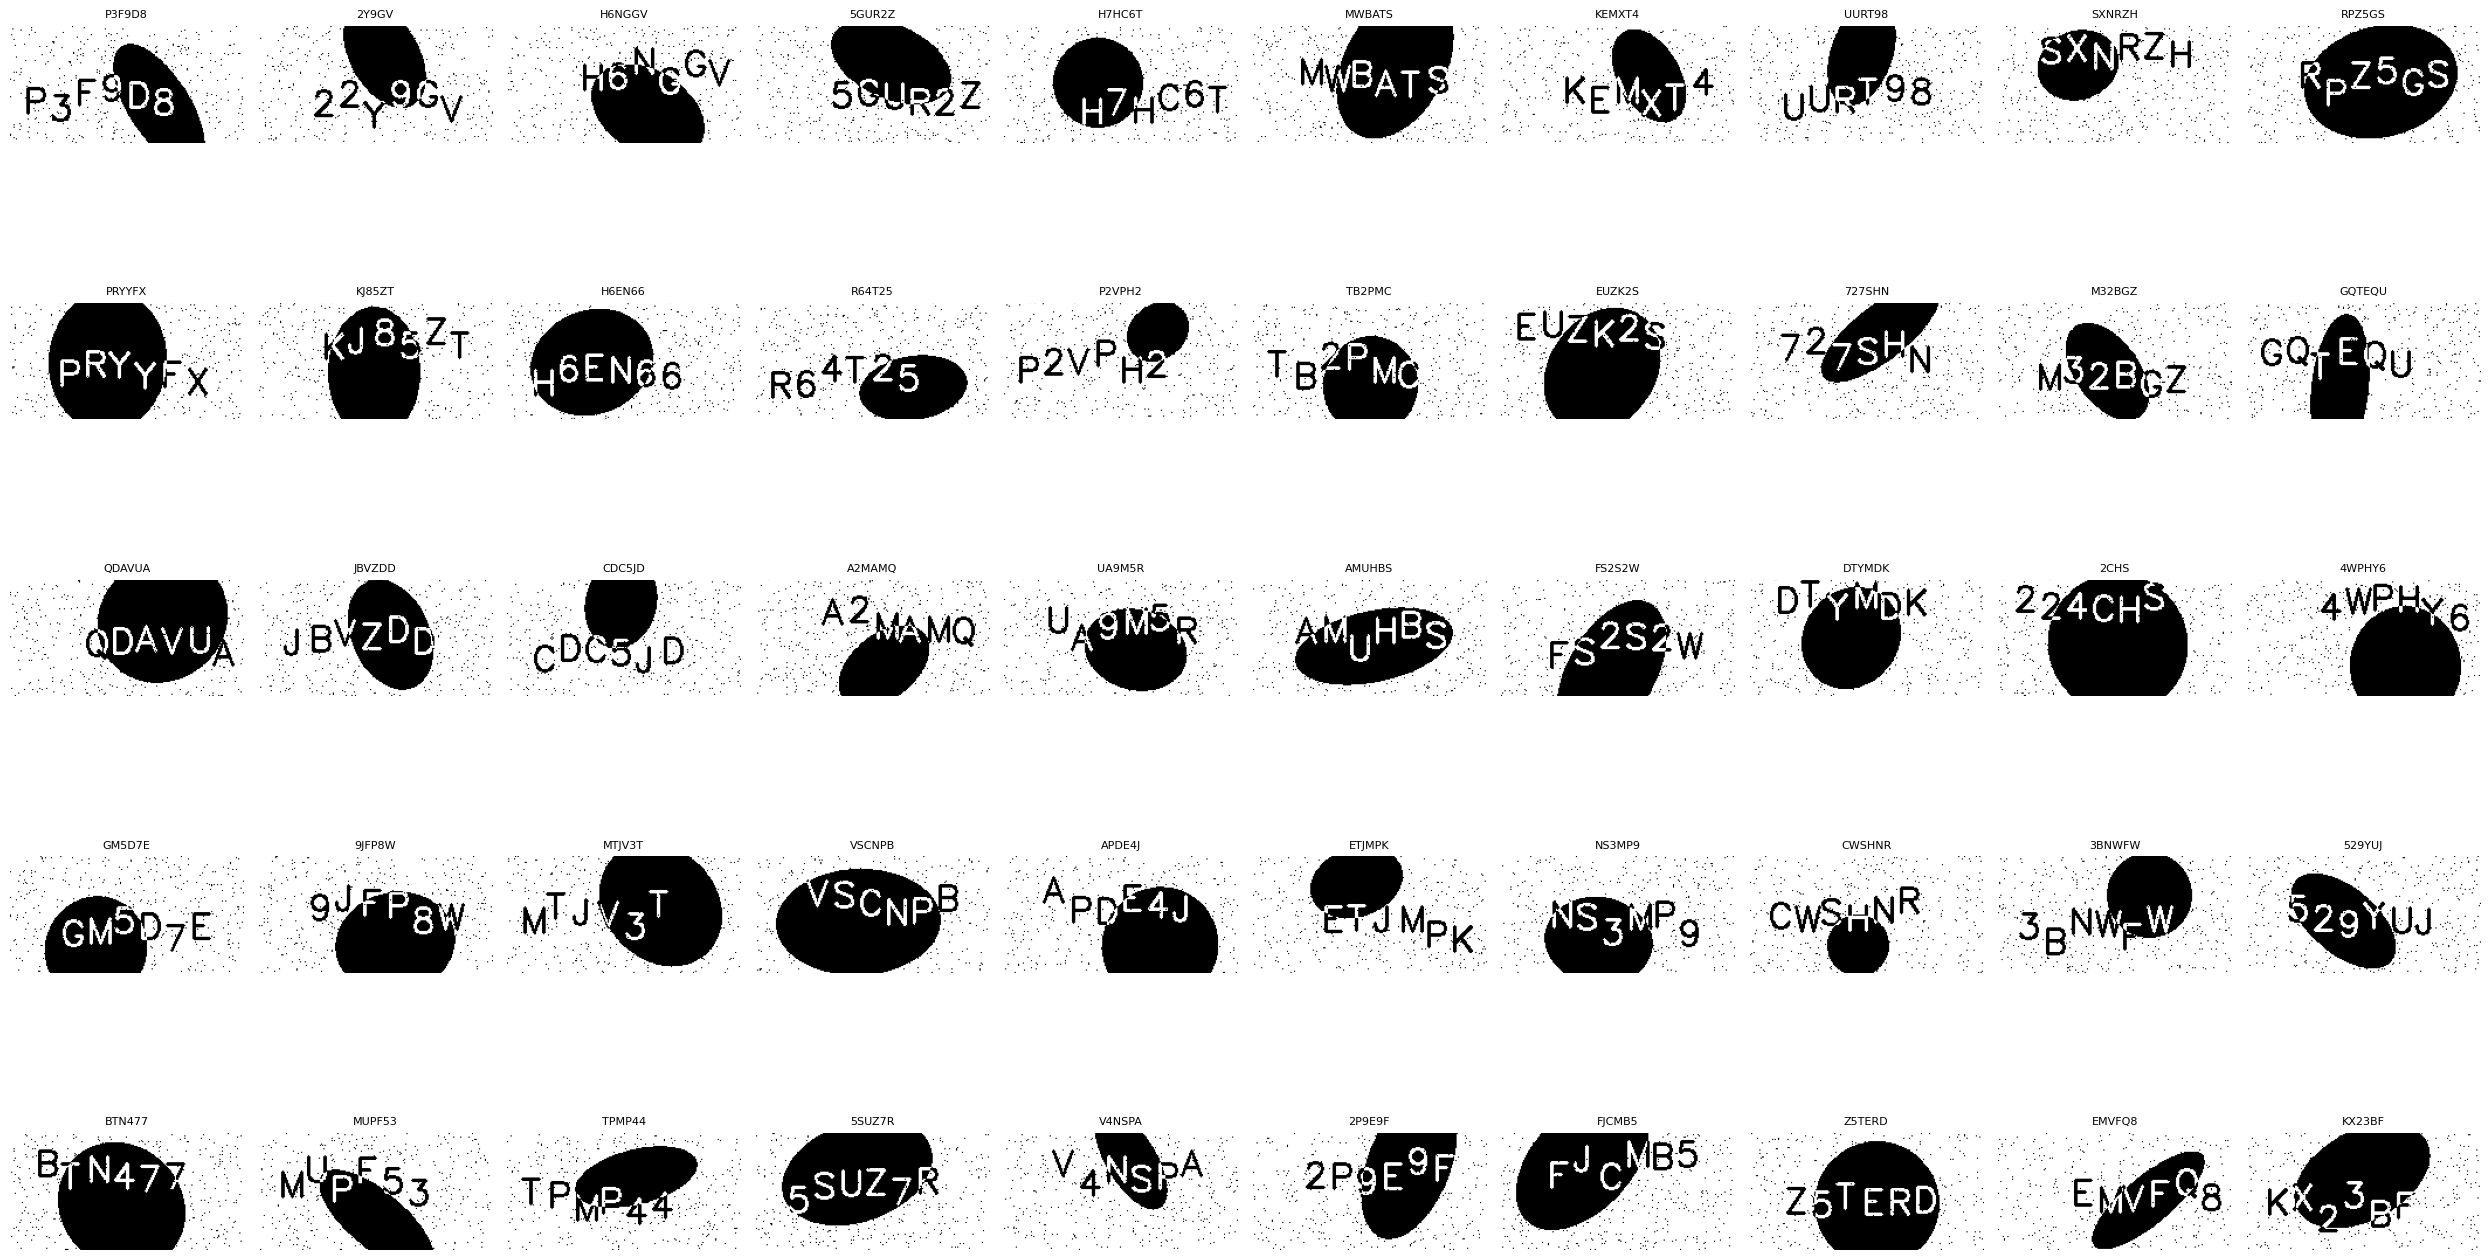

In [ ]:
random_images = random.sample(
    test_image_files,
    50
)

fig, axes = plt.subplots(
    5,
    10,
    figsize=(25, 15)
)

for ax, image_name in zip(
    axes.flatten(),
    random_images
):

    image_path = os.path.join(
        test_path,
        image_name
    )

    prediction = predict_image(image_path)

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    ax.imshow(image, cmap="gray")
    ax.set_title(prediction, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
prediction_texts = [
    pred
    for _, pred in predictions
]

print("Total predictions:", len(predictions))

lengths = [len(p) for p in prediction_texts]

print("Min length:", min(lengths))
print("Max length:", max(lengths))
print("Unique predictions:", len(set(prediction_texts)))

Total predictions: 5000
Min length: 4
Max length: 8
Unique predictions: 5000


In [ ]:
length_counts = Counter(
    len(p)
    for p in prediction_texts
)

total_predictions = len(prediction_texts)

rows = []

for length in sorted(length_counts.keys()):

    count = length_counts[length]

    percentage = (
        100 * count / total_predictions
    )

    rows.append(
        [length, count, percentage]
    )

length_df = pd.DataFrame(
    rows,
    columns=[
        "Length",
        "Count",
        "Percentage"
    ]
)

print(length_df)

   Length  Count  Percentage
0       4      5        0.10
1       5     73        1.46
2       6   4864       97.28
3       7     57        1.14
4       8      1        0.02


Analysis of the 5,000 unseen test images showed that `97.28%` of predictions had the expected six-character length. The remaining cases were mainly insertion and deletion issues from greedy CTC decoding, so beam-search decoding is a practical future improvement for better sequence consistency.


## 20. Submission File Creation

The submission file is generated with the required columns:

```text
image,prediction
```

Rows are sorted by the numeric test image id, then written to `submission_PallaviKumari_24119037.csv`.


In [ ]:
submission = pd.DataFrame(
    predictions,
    columns=["image", "prediction"]
)

print(submission.head())
print()
print("Total rows:", len(submission))

In [ ]:
submission = submission.sort_values(
    by="image",
    key=lambda col: col.apply(image_number)
).reset_index(drop=True)

In [ ]:
print(submission.isnull().sum())

In [ ]:
print(
    submission["prediction"]
    .str.len()
    .value_counts()
    .sort_index()
)

In [ ]:
SUBMISSION_DIR = Path("../submissions") if Path("../submissions").exists() else Path(".")
submission_path = SUBMISSION_DIR / "submission_PallaviKumari_24119037.csv"

submission.to_csv(
    submission_path,
    index=False
)

print(f"Saved final submission to {submission_path}")
print("Total rows:", len(submission))

## 21. Limitations

This solution uses greedy CTC decoding, which can produce insertions or deletions when the model is uncertain. The validation mistakes show that repeated characters and visually similar symbols remain challenging. The notebook does not include additional experiments with beam search, attention models, transformers, or external language models, so no claims are made about those alternatives.


## 22. Future Improvements

These are realistic extensions of the current CRNN solution. They were not used to produce the reported validation accuracy or CER, so they should be treated as future work rather than completed experiments.

| Improvement | Why it could help | Connection to this CRNN solution |
| --- | --- | --- |
| Data augmentation | Random blur, noise, affine shifts, cutout/occlusion, contrast changes, and elastic deformation could improve robustness to the same distortions seen in the dataset | The current CNN feature extractor would see more varied distorted examples during training, reducing overfitting to the observed training images |
| Beam search decoding | Greedy CTC decoding can create insertions/deletions, especially around repeated characters | Beam search could keep multiple likely CTC paths and may reduce sequence-level errors without changing the trained CNN-BiLSTM model |
| Attention OCR | Attention-based decoders can learn where to focus while generating each character | This could be explored as an alternative decoder when CTC struggles with repeated characters or highly irregular spacing |
| Transformer OCR | Vision transformers or CNN-transformer hybrids can model wider visual context than recurrent layers | A transformer sequence encoder could replace or augment the BiLSTM, but it would need careful validation and likely more tuning |

The most direct next step is beam-search decoding because it can be tested on top of the existing trained CRNN. Augmentation is the next most practical training improvement. Attention OCR and transformer OCR are larger architectural experiments and should be compared only after implementing and validating them properly.


## 23. Conclusion

The final CRNN pipeline successfully learns distorted visual sequence recognition from grayscale images using CNN features, BiLSTM sequence modeling, and CTC training. On the held-out validation split, the notebook reports `95.95%` exact-sequence accuracy, `98.83%` character-level accuracy, and `0.0069` CER. The generated CSV contains predictions for all 5,000 test images in the required competition format.
